In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Detección de outliers con ***z_score***

Parte del supuesto en el que los datos siguen una distribución Normal

1. Calcular media y desviación estándar
2. Estandarizar cada observación (la media es 0)
3. Definir los umbrales para valores extremos z = +- 3

In [32]:
def graficar_outliers(serie, fechas, outliers = None):
    ax = serie.plot(alpha = 0.7)

    serie.loc[fechas].plot(ax = ax, style = 'bo')

    if outliers is not None:
        outliers.plot(ax = ax, style = 'rx')
        plt.legend(['Serie de tiempo', 'Outliers conocidos', 'Outliers desconocidos'])
    else:
        plt.legend(['Serie de tiempo', 'Outliers conocidos'])
    
    plt.xlabel('Fecha')
    plt.ylabel('# pasajeros')


In [33]:
def outliers_zscore(serie, umbral = 3):
    zs = (serie - serie.mean())/(serie.std())
    outliers = serie[(zs.to_numpy() > umbral) | (zs.to_numpy() < -umbral)]

    return outliers

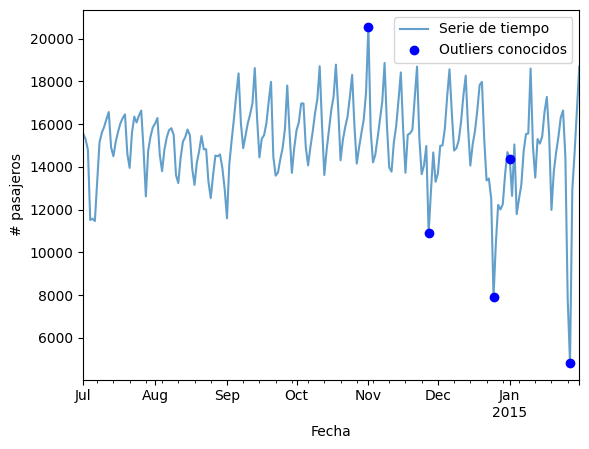

In [34]:
taxis = pd.read_csv('datos/taxis_ny.csv',
                    parse_dates=['tiempo'],
                    index_col='tiempo')
fechas = [
    '2014-11-01',
    '2014-11-27',
    '2014-12-25',
    '2015-01-01',
    '2015-01-27']

tx_diaria = taxis.resample('D').mean()

graficar_outliers(tx_diaria, fechas)

                     obs
tiempo                  
2014-11-01  20553.500000
2014-11-27  10899.666667
2014-12-25   7902.125000
2014-12-26  10397.958333
2015-01-26   7818.979167
2015-01-27   4834.541667


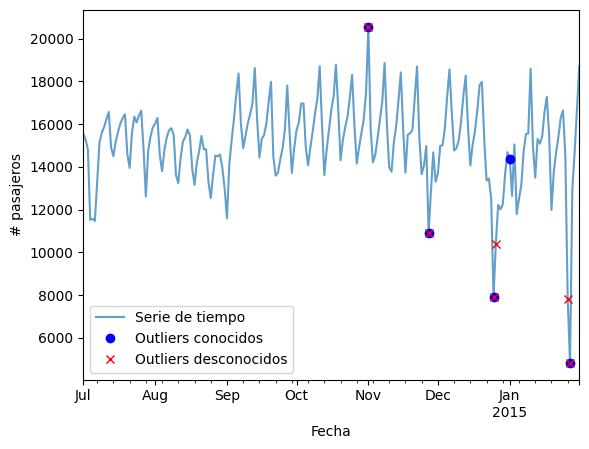

In [49]:
outliers_diario = outliers_zscore(tx_diaria, 2)
print(outliers_diario)

graficar_outliers(tx_diaria, fechas, outliers_diario)

<Axes: ylabel='Count'>

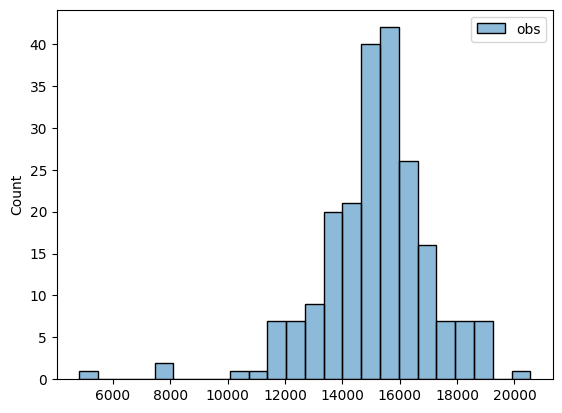

In [50]:
sns.histplot(tx_diaria)